## Setup

In [1]:
import pandas as pd
import sys
import os

# Set up paths to access the data and the eda module
sys.path.append(os.path.abspath(os.path.join('..')))
import eda

# Paths for input and output
FEATURES_CSV = "../../output/features.csv"
OUTPUT_DIR = "../../output/"

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Load dataset (Generated from pipeline.ipynb)
df = pd.read_csv(FEATURES_CSV)

# Define feature list for analysis
shape_features = [
    "Area", "Perimeter", "Solidity", "Eccentricity", "Circularity", 
    "Aspect Ratio", "Convexity", "Irregularity Index", "Roundness"
]

print(f"Dataset loaded: {len(df)} records found.")


Dataset loaded: 1664 records found.


## Correlation Analysis

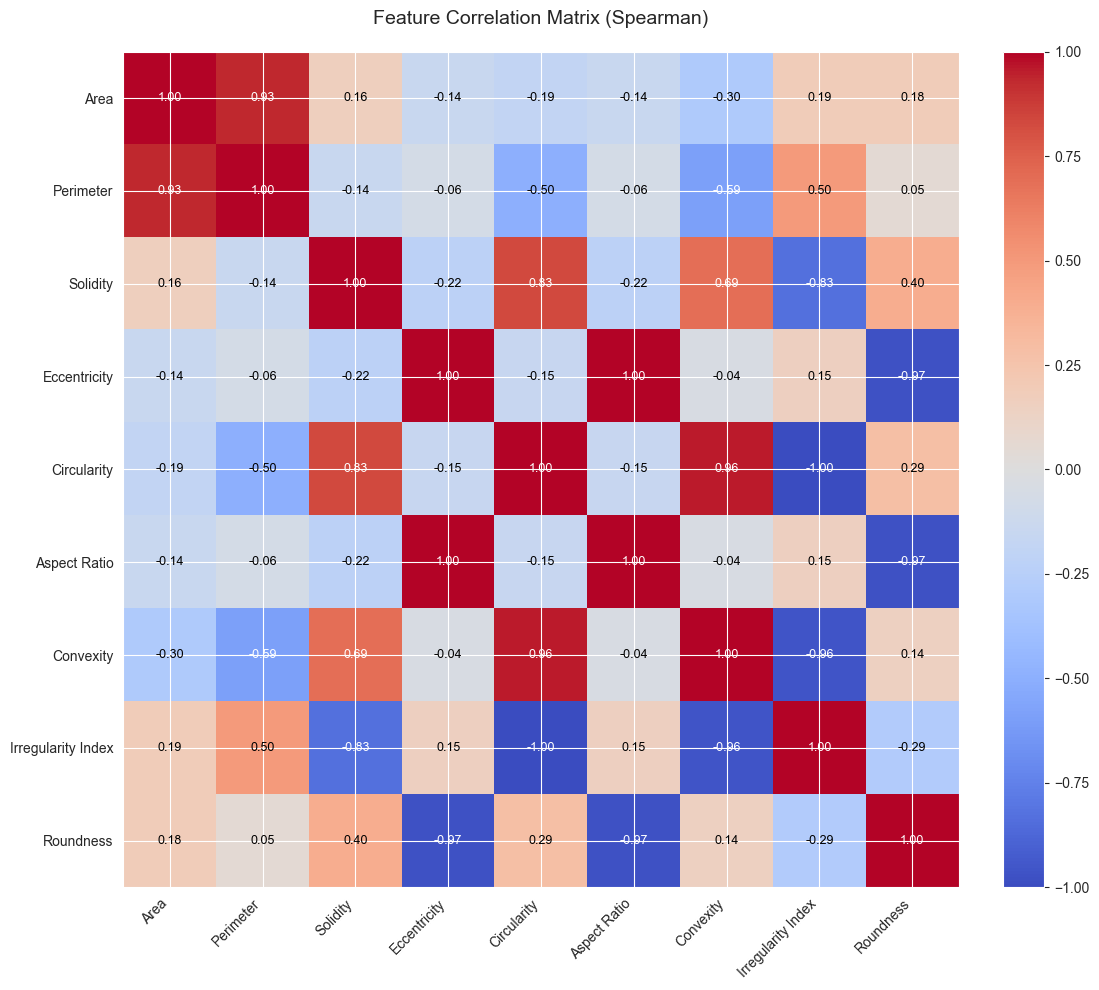

In [2]:
# Analyze Correlations: Calculate and visualize the correlation matrix
# Identifying multicollinearity to guide feature engineering
eda.plot_correlation_matrix(
    df, 
    shape_features, 
    save_path=os.path.join(OUTPUT_DIR, "correlation_matrix.png"),
    csv_path=f"{OUTPUT_DIR}correlation_matrix.csv"
)

## Class Distribution Analysis

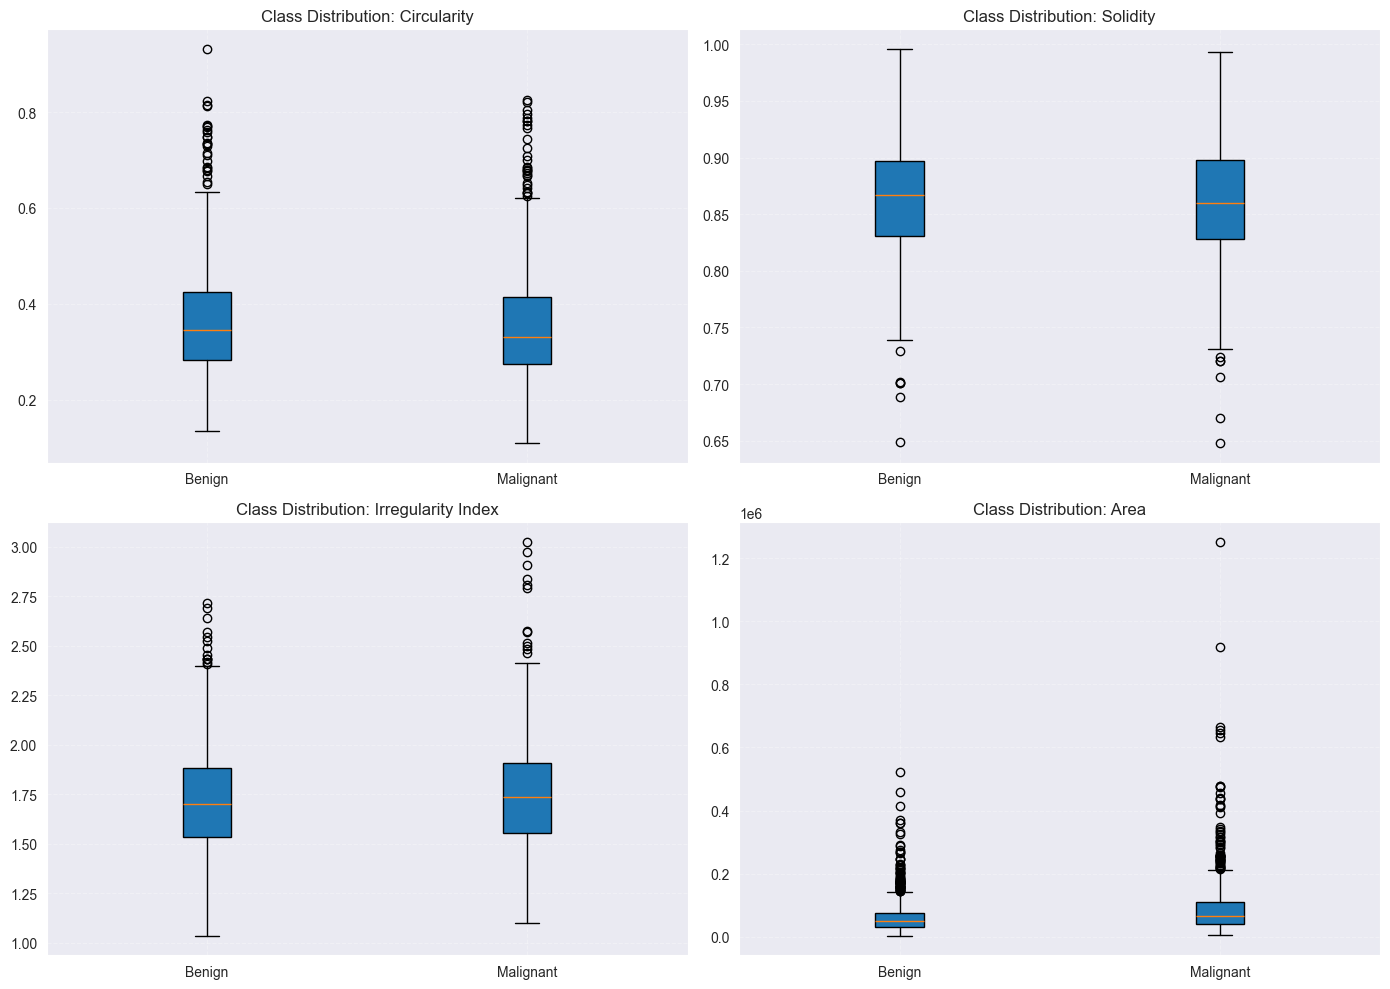

In [3]:
# Class Distribution Analysis: Estimate class separability
# Focusing on key shape descriptors identified in project documentation
key_metrics = ["Circularity", "Solidity", "Irregularity Index", "Area"]

eda.plot_class_distributions(
    df, 
    key_metrics, 
    save_path=os.path.join(OUTPUT_DIR, "class_separability.png")
)

## Outlier Detection

In [4]:
# Outlier Detection: Identify and analyze outliers using IQR method
report = eda.get_outliers_report(df, shape_features)
report.to_csv(f"{OUTPUT_DIR}outlier_report.csv")
display(report.sort_values(by='count', ascending=False))

,count,percentage
Area,143.0,8.59
Perimeter,91.0,5.47
Aspect Ratio,91.0,5.47
Circularity,52.0,3.12
Roundness,32.0,1.92
Convexity,31.0,1.86
Irregularity Index,23.0,1.38
Solidity,11.0,0.66
Eccentricity,6.0,0.36
